<a href="https://colab.research.google.com/github/g019-expert/BMEN5801_PS1/blob/main/BMEN5801_ps1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!git clone https://github.com/g019-expert/BMEN5801_PS1.git

import os

DATA = 'BMEN5801_PS1/data'
RESULTS = 'BMEN5801_PS1/figures'
os.makedirs(RESULTS, exist_ok=True)
print(sorted(os.listdir(DATA)))

fatal: destination path 'BMEN5801_PS1' already exists and is not an empty directory.
['ALL_BoneMarrowSmear.png', 'GSE54456_RPKM_samples.csv', 'GSE54456_labels.csv', 'ecg-svt.h5']


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import matplotlib.pyplot as plt
from scipy import signal, stats

# given that sampled at same hz for all leads
FS = 977.0 # hz

LIMB = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF']
CHEST = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']


Problem 1

In [7]:
df = pd.read_hdf(f'{DATA}/ecg-svt.h5')

print(df.shape)
print(df.columns.tolist())
print(df['record'].value_counts())
print(df.head())
print(df.index.min(), df.index.max())

(1191633, 13)
['record', 'I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
record
x0025    650620
x0021    541013
Name: count, dtype: int64
  record      I     II    III    aVR    aVL    aVF     V1     V2     V3  \
0  x0021  0.010 -0.053 -0.054  0.044  0.039 -0.044 -0.082 -0.175 -0.295   
1  x0021  0.019 -0.058 -0.064  0.049  0.039 -0.053 -0.087 -0.165 -0.290   
2  x0021  0.019 -0.067 -0.069  0.049  0.049 -0.058 -0.087 -0.170 -0.290   
3  x0021  0.014 -0.063 -0.064  0.044  0.044 -0.044 -0.082 -0.160 -0.290   
4  x0021  0.014 -0.038 -0.044  0.029  0.039 -0.024 -0.087 -0.155 -0.286   

      V4     V5     V6  
0 -0.124 -0.048 -0.024  
1 -0.124 -0.043 -0.029  
2 -0.124 -0.048 -0.034  
3 -0.124 -0.043 -0.029  
4 -0.124 -0.048 -0.034  
0 1191632


x0021: first R at 0.176 s, RR = 0.379 s (158.4 bpm)
x0025: first R at 0.192 s, RR = 0.640 s (93.8 bpm)


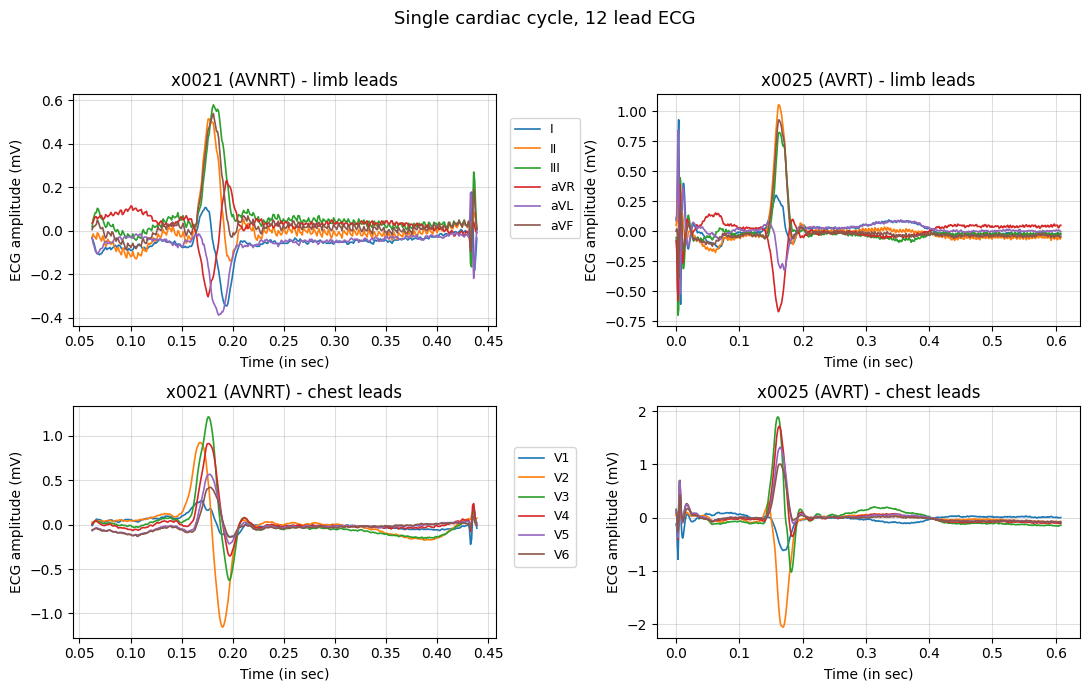

In [8]:
# 1(a) limb leads top, chest leads below (x0021 on left and x0025 right col)

PATIENTS = [('x0021','AVNRT'), ('x0025','AVRT')]

from scipy.signal import find_peaks

fig, axes = plt.subplots(2, 2, figsize=(11, 7))


# return (low, high) sample bounds around the first cardiac cycle
# and window is sized from the local RR interval
def first_beat_window(sig, fs=FS):
  # true baseline
    x = sig - np.median(sig[:int(5*fs)])
    pk, _ = find_peaks(np.abs(x), height=0.5*np.max(np.abs(x[:int(10*fs)])),
                       distance=int(0.2*fs))
    r0, r1 = pk[0], pk[1]
    rr = (r1 - r0) / fs
    return max(int(r0 - 0.30*rr*fs), 0), int(r0 + 0.70*rr*fs), rr

# locate each patient record
def get_record(df, rec):
  return df.loc[df['record'] == rec].reset_index(drop=True)

for col, (rec, dx) in enumerate(PATIENTS):
    d = get_record(df, rec)
    "lead II timing reference"
    lo, hi, rr = first_beat_window(d['II'].values)
    t = np.arange(lo, hi) / FS

    for row, leads in enumerate([LIMB, CHEST]):
        ax = axes[row, col]
        for L in leads:
            v = d[L].values[lo:hi] - np.median(d[L].values[:int(5*FS)])
            ax.plot(t, v, lw=1.2, label=L)
        ax.set_xlabel('Time (in sec)')
        ax.set_ylabel('ECG amplitude (mV)')
        ax.set_title(f'{rec} ({dx}) - {"limb" if row==0 else "chest"} leads')
        ax.grid(True, alpha=0.4)

    print(f'{rec}: first R at {lo/FS + 0.30*rr:.3f} s, RR = {rr:.3f} s '
          f'({60/rr:.1f} bpm)')

fig.legend(handles=axes[0,0].get_legend_handles_labels()[0],
           loc='center', bbox_to_anchor=(0.5, 0.74), frameon=True, fontsize=9)
fig.legend(handles=axes[1,0].get_legend_handles_labels()[0],
           loc='center', bbox_to_anchor=(0.5, 0.27), frameon=True, fontsize=9)

fig.suptitle('Single cardiac cycle, 12 lead ECG', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(wspace=0.38)
fig.savefig(f'{RESULTS}/p1a_first_beat.png', dpi=200, bbox_inches='tight')
plt.show()